In [77]:
import numpy as np

import numpy as np

from matplotlib import pyplot as plt

def init_random_vec(d):
    a_vec = ((np.random.rand(d) * 2) - 1) * np.pi
    c_vec = np.exp(a_vec*1j)
    return c_vec
def init_ones_vec(d):
    a_vec = np.ones(shape=d)
    c_vec = np.exp(a_vec*1j)
    return c_vec

def init_random_mat(d1, d2):
    a_vec = ((np.random.rand(d1, d2) * 2) - 1) * np.pi
    c_vec = np.exp(a_vec*1j)
    return c_vec

def forward_opp(mat1, mat2):
    d = mat1.shape[0]
    return np.matmul(mat1, mat2)/d
def s_opp(mat1, mat2):
    d = mat1.shape[0]
    return np.matmul(mat1, np.transpose(np.conj(mat2)))/d

def similarity(vec1, vec2):
    d = vec1.shape[0]
    return np.real(np.dot(vec1, np.conj(vec2))/d)
def similarity2(vec1, vec2):
    d = vec1.shape[0]
    return np.real(normalize(np.array([np.dot(vec1, np.conj(vec2))/d])))

def bind(vec1, vec2):
    return vec1 * vec2

def inverse(vec):
    return normalize(np.conj(vec)) / np.absolute(vec)

def unbind(vec1, vec2):
    return bind(vec1, inverse(vec2))

def bundle(vec1, *args):
    new_vec = vec1
    for vec in args:
        new_vec = new_vec + vec
    #new_vec = new_vec / (len(args)+1)
    return new_vec
    
def normalize(vec):
    a_vec = np.angle(vec)
    return np.exp(a_vec*1j)

def frac_power(c_vec, x):
    a_vec = np.angle(c_vec)
    a_vec = a_vec * x
    c_vec = np.exp(a_vec*1j)
    return c_vec

In [13]:
dims = 10000

In [40]:
event_vec = init_random_vec(dims)
event_vec1 = init_random_vec(dims)
event_vec2 = init_random_vec(dims)
event_vec3 = init_random_vec(dims)
event_vec4 = init_random_vec(dims)
event_1 = init_random_vec(dims)
event_2 = init_random_vec(dims)

bundle_1 = bundle(event_1, event_1, event_2)
print(similarity(bundle_1, event_1), similarity(bundle_1, event_2))

event_query = normalize(bundle(event_vec1, event_vec2, event_vec3))
bundle_2 = bundle(bind(event_vec1, event_1), bind(event_vec2, event_1), bind(event_vec3, event_2), bind(event_vec4, event_2))
q_bundle_2 = unbind(bundle_2, event_query)
print(similarity(q_bundle_2, event_1), similarity(q_bundle_2, event_2))
event_query_2 = normalize(bundle(event_vec2, event_vec3))
q_bundle_3 = unbind(bundle_2, event_query_2)
print(similarity(q_bundle_3, event_1), similarity(q_bundle_3, event_2))

2.0067386596959493 1.0134773193918982
1.041953018217553 0.5257565081549257
0.6407967604704257 0.6327675153625785


In [41]:
event_vec = init_random_vec(dims)
event_vec1 = init_random_vec(dims)
event_vec2 = init_random_vec(dims)
event_vec3 = init_random_vec(dims)
event_vec4 = init_random_vec(dims)
event_1 = init_random_vec(dims)
event_2 = init_random_vec(dims)

bundle_1 = normalize(bundle(event_1, event_1, event_2))
print(similarity(bundle_1, event_1), similarity(bundle_1, event_2))

event_query = normalize(bundle(event_vec1, event_vec2, event_vec3))
bundle_2 = normalize(bundle(bind(event_vec1, event_1), bind(event_vec2, event_1), bind(event_vec3, event_2), bind(event_vec4, event_2)))
q_bundle_2 = unbind(bundle_2, event_query)
print(similarity(q_bundle_2, event_1), similarity(q_bundle_2, event_2))
event_query_2 = normalize(bundle(event_vec2, event_vec3))
q_bundle_3 = unbind(bundle_2, event_query_2)
print(similarity(q_bundle_3, event_1), similarity(q_bundle_3, event_2))

0.9343235238504604 0.2543908194129643
0.474039582115273 0.2741883212512008
0.2914189781118157 0.29013064505014263


In [53]:
event_vecs = [init_random_vec(dims) for _ in range(100)]
event_A = init_random_vec(dims)
event_B = init_random_vec(dims)
event_bundle = bundle(*[bind(ev, event_A) if i < 90 else bind(ev, event_B) for i, ev in enumerate(event_vecs)])

In [63]:
def event_prob(bundle_vec, event_query, event_1, event_2):
    prob_1 = max(similarity(unbind((bundle_vec), event_query), event_1), 0)
    prob_2 = max(similarity(unbind((bundle_vec), event_query), event_2), 0)
    if prob_1 + prob_2 == 0:
        return 0
    return prob_1/(prob_1 + prob_2)

In [49]:
event_query = normalize(bundle(*event_vecs))
print(similarity(unbind(normalize(event_bundle), event_query), event_A), similarity(unbind(normalize(event_bundle), event_query), event_B))
event_query2 = normalize(bundle(*event_vecs[:91]))
print(similarity(unbind(normalize(event_bundle), event_query2), event_A), similarity(unbind(normalize(event_bundle), event_query2), event_B))

0.8358945702454661 0.12126039379908386
0.8882362388792776 0.020605307326091293


In [58]:
event_query = normalize(bundle(*event_vecs))
print(event_prob(event_bundle, event_query, event_A, event_B))

0.8971230664729161


In [87]:
errors = []
fracs = 1000
event_vecs = [init_ones_vec(dims) for _ in range(fracs)]
event_A = init_random_vec(dims)
event_B = init_random_vec(dims)
event_query = normalize(bundle(*event_vecs))
probs = []
pred_probs = []
for x in range(fracs+1):
    prob = (x)/fracs
    event_bundle = bundle(*[bind(ev, event_A) if i < x else bind(ev, event_B) for i, ev in enumerate(event_vecs)])
    pred_prob = event_prob(normalize(event_bundle), event_query, event_A, event_B)
    print(prob, pred_prob, (prob - pred_prob)**2)
    errors.append((prob - pred_prob)**2)
    probs.append(prob)
    pred_probs.append(pred_prob)




0.0 0.007580669563887574 5.746655103685142e-05
0.001 0.008070919671460583 4.999790500024823e-05
0.002 0.008561667547607843 4.305548100532993e-05
0.003 0.00905291506019038 3.6637780725879516e-05
0.004 0.009544664087617439 3.074329984451453e-05
0.005 0.010036916518924329 2.5370528018612777e-05
0.006 0.010529674253850976 2.0517948846000394e-05
0.007 0.011022939202921203 1.6184039830400283e-05
0.008 0.011516713287522795 1.2367272346639385e-05
0.009 0.012010998439988103 9.066111605610796e-06
0.01 0.012505796603675717 6.279016618992755e-06
0.011 0.013001109733052492 4.004440163717419e-06
0.012 0.01349693979377667 2.24082874619214e-06
0.013 0.013993288762781527 9.866225662680573e-07
0.014 0.014490158628359978 2.402554809557349e-07
0.015 0.014987551390249773 1.5496788471342128e-10
0.016 0.015485469059719694 2.647420885057357e-07
0.017 0.015983913659656346 1.0324314510329628e-06
0.018 0.016482887224651868 2.301631173124507e-06
0.019 0.016982391801092525 4.070742844298663e-06
0.02 0.017482429447

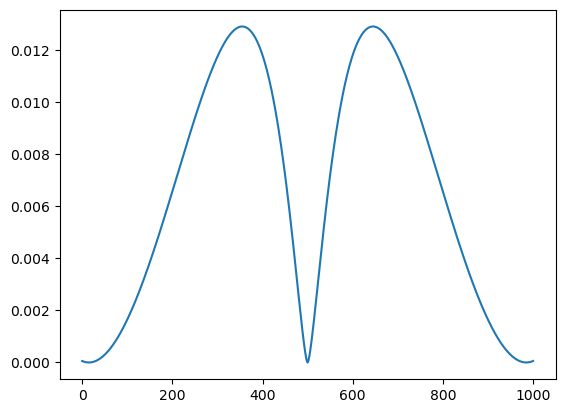

In [88]:
from matplotlib import pyplot as plt

plt.plot(errors)
plt.show()

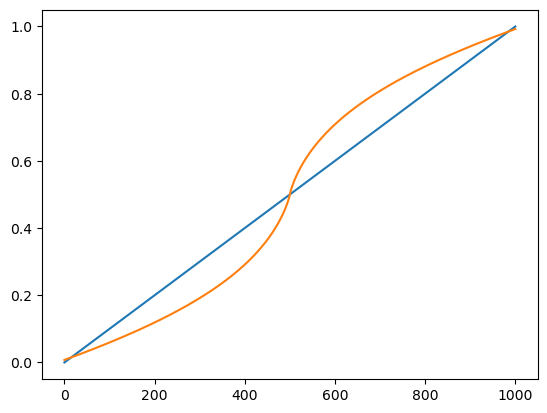

In [89]:
from matplotlib import pyplot as plt

plt.plot(probs)
plt.plot(pred_probs)
plt.show()